# Importing data and libraries

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import scipy

In [3]:
path = r'/Users/mariatirado/29-10-2025 Instacart Basket Analysis'

In [5]:
ords_prods_merge_updated = pd.read_pickle(os.path.join(
    path, '02 Data', 'Prepared Data', 'ords_prods_merge_spending_frequency.pkl'))

In [6]:
ords_prods_merge_updated.shape

(32432460, 24)

In [7]:
ords_prods_merge_updated.head(5)

,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_id,add_to_cart_order,reordered,...,price_range_loc,day_type,busiest_days_new,busiest_period_of_day,max_order,loyalty_flag,spending_flag,spending_mean,median_days,frequency_flag
0,2539329,1,prior,1,2,8,NaN,196,1,0,...,Mid-range product,Regularly busy,Regularly busy,Average orders,10,New customer,Low spender,6.367797,20.5,Non-frequent customer
1,2539329,1,prior,1,2,8,NaN,14084,2,0,...,Mid-range product,Regularly busy,Regularly busy,Average orders,10,New customer,Low spender,6.367797,20.5,Non-frequent customer
2,2539329,1,prior,1,2,8,NaN,12427,3,0,...,Low-range product,Regularly busy,Regularly busy,Average orders,10,New customer,Low spender,6.367797,20.5,Non-frequent customer
3,2539329,1,prior,1,2,8,NaN,26088,4,0,...,Low-range product,Regularly busy,Regularly busy,Average orders,10,New customer,Low spender,6.367797,20.5,Non-frequent customer
4,2539329,1,prior,1,2,8,NaN,26405,5,0,...,Low-range product,Regularly busy,Regularly busy,Average orders,10,New customer,Low spender,6.367797,20.5,Non-frequent customer


<Axes: xlabel='order_dow'>

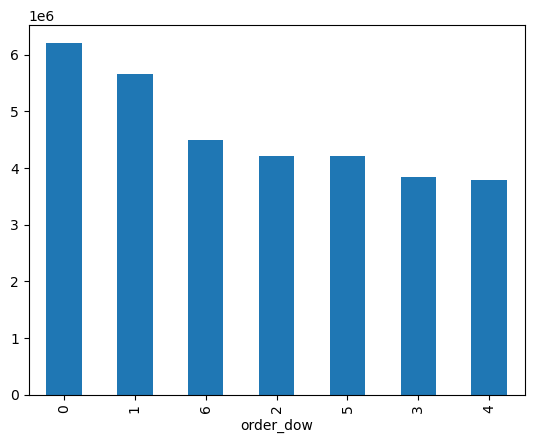

In [10]:
ords_prods_merge_updated['order_dow'].value_counts().plot.bar()

<Axes: xlabel='order_dow'>

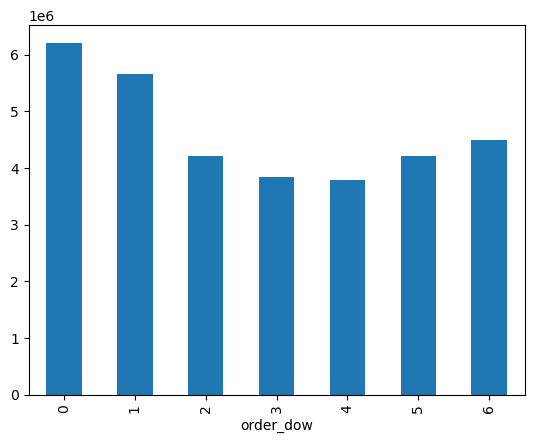

In [11]:
ords_prods_merge_updated['order_dow'].value_counts().sort_index().plot.bar()

<Axes: xlabel='order_dow'>

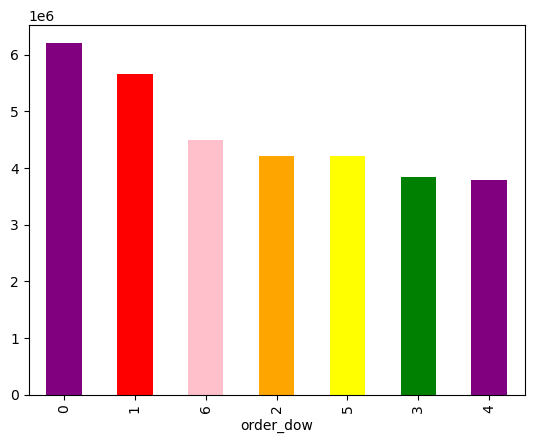

In [13]:
ords_prods_merge_updated['order_dow'].value_counts().plot.bar(color =['purple', 'red', 'pink', 'orange', 'yellow', 'green'])

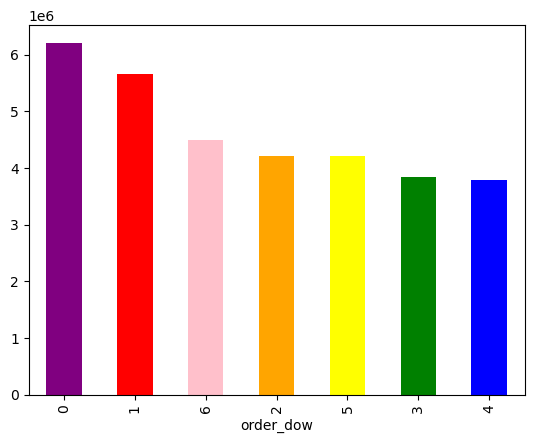

In [15]:
bar = ords_prods_merge_updated['order_dow'].value_counts().plot.bar(color =['purple', 'red', 'pink', 'orange', 'yellow', 'green', 'blue'])

In [17]:
bar.figure.savefig(os.path.join(path, '04 Analysis','Visualizations', 'bar_orders_dow.png'))

# Histogram

<Axes: ylabel='Frequency'>

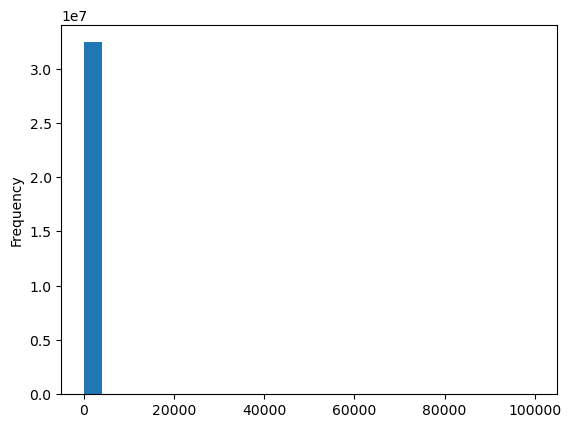

In [19]:
ords_prods_merge_updated['prices'].plot.hist(bins = 25)

In [20]:
ords_prods_merge_updated['prices'].mean()

np.float64(11.981485949570288)

In [21]:
ords_prods_merge_updated['prices'].median()

7.4

In [22]:
ords_prods_merge_updated['prices'].max()

99999.0

# Scatterplot

<Axes: xlabel='prices', ylabel='prices'>

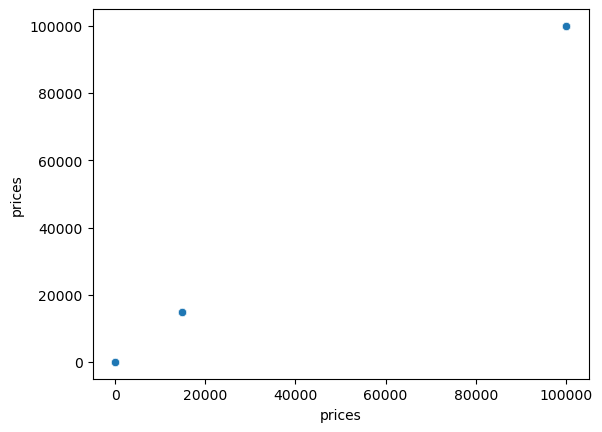

In [23]:
sns.scatterplot(x = 'prices', y = 'prices',data = ords_prods_merge_updated)

# Futher exploratory checks

In [25]:
ords_prods_merge_updated.loc[ords_prods_merge_updated['prices'] > 100]

,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_id,add_to_cart_order,reordered,...,price_range_loc,day_type,busiest_days_new,busiest_period_of_day,max_order,loyalty_flag,spending_flag,spending_mean,median_days,frequency_flag
1576,912404,17,prior,12,2,14,5.0,21553,5,0,...,High-range product,Regularly busy,Regularly busy,Average orders,40,Regular customer,High spender,108.648299,5.0,Frequent customer
1638,603376,17,prior,22,6,16,4.0,21553,3,1,...,High-range product,Regularly busy,Regularly busy,Average orders,40,Regular customer,High spender,108.648299,5.0,Frequent customer
16532,3264360,135,prior,2,2,21,13.0,21553,6,0,...,High-range product,Regularly busy,Regularly busy,Most orders,4,New customer,High spender,1154.792308,12.0,Regular customer
16538,892534,135,prior,3,0,8,12.0,21553,3,1,...,High-range product,Busiest day,Busiest days,Average orders,4,New customer,High spender,1154.792308,12.0,Regular customer
53707,229704,342,prior,8,1,19,30.0,21553,9,0,...,High-range product,Regularly busy,Busiest days,Most orders,16,Regular customer,High spender,114.426619,23.0,Non-frequent customer
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32348036,3172853,205650,prior,18,1,9,7.0,21553,17,1,...,High-range product,Regularly busy,Busiest days,Average orders,25,Regular customer,High spender,349.193678,6.0,Frequent customer
32375268,2504315,205818,prior,3,5,15,3.0,21553,13,0,...,High-range product,Regularly busy,Regularly busy,Average orders,25,Regular customer,High spender,169.226630,12.5,Regular customer
32375278,1108388,205818,prior,5,4,5,1.0,21553,5,1,...,High-range product,Least busy,Slowest days,Fewest orders,25,Regular customer,High spender,169.226630,12.5,Regular customer
32408108,1916142,206049,prior,1,2,17,NaN,21553,2,0,...,High-range product,Regularly busy,Regularly busy,Most orders,5,New customer,High spender,938.031250,7.0,Frequent customer


# Mark the high values as missing

In [26]:
ords_prods_merge_updated.loc[ords_prods_merge_updated['prices'] >100, 'prices'] = np.nan

In [27]:
ords_prods_merge_updated['prices'].max()

25.0

<Axes: ylabel='Frequency'>

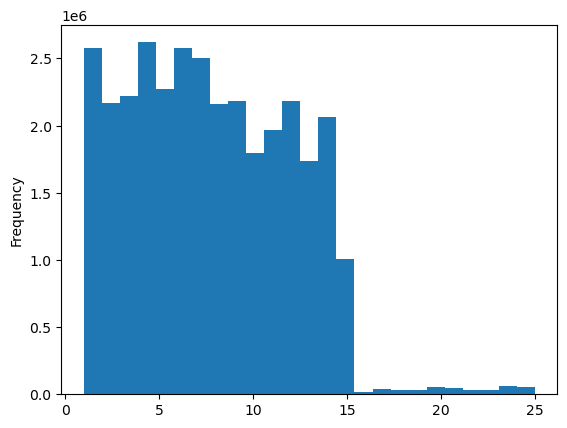

In [28]:
ords_prods_merge_updated['prices'].plot.hist(bins = 25)

<Axes: ylabel='Frequency'>

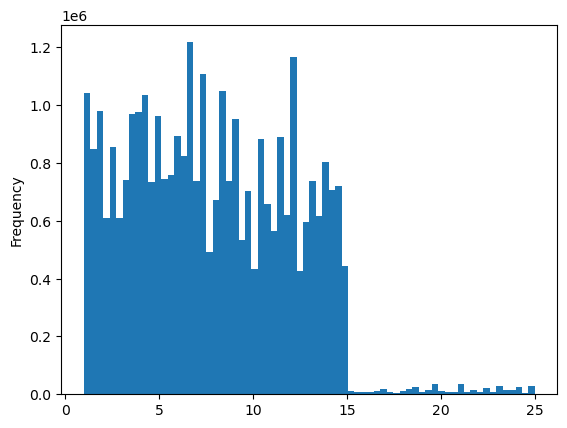

In [29]:
ords_prods_merge_updated['prices'].plot.hist(bins = 70)

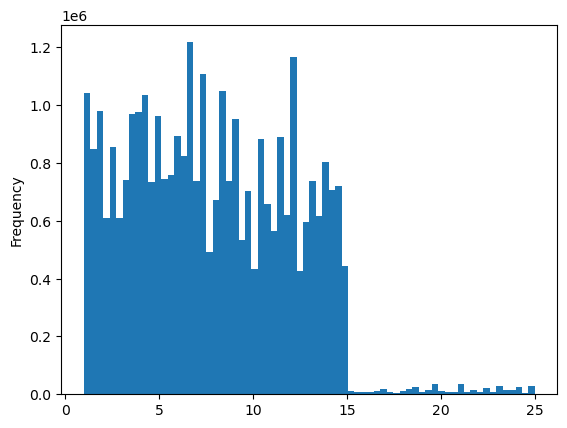

In [31]:
hist = ords_prods_merge_updated['prices'].plot.hist(bins=70)

In [32]:
hist.figure.savefig(os.path.join(path, '04 Analysis','Visualizations', 'hist_orders_dow.png'))

# Line-chart

In [33]:
df = ords_prods_merge_updated[:2000000]

In [34]:
df.shape

(2000000, 24)

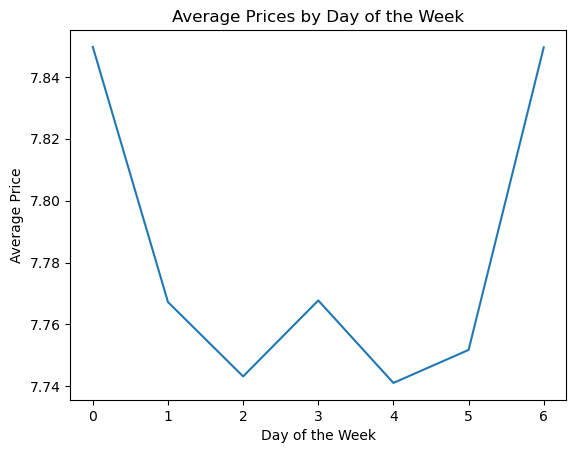

In [35]:
import matplotlib.pyplot as plt

# Create the plot
df.groupby('order_dow')['prices'].mean().plot.line()

# Add titles and labels
plt.title('Average Prices by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Average Price')
plt.show()

# Sampling data 

In [37]:
np.random.seed(4)
dev = np.random.rand(len(ords_prods_merge_updated)) <= 0.7

In [39]:
np.random.rand(10)

array([0.72138301, 0.21075695, 0.11165779, 0.65296654, 0.43877032,
       0.13175012, 0.26176024, 0.46569745, 0.64136988, 0.40781616])

In [40]:
# Store 70% of the sample in the dataframe big
big = ords_prods_merge_updated[dev]

# Store 30% of the sample in the dataframe small
small = ords_prods_merge_updated[~dev]

In [42]:
len(ords_prods_merge_updated)

32432460

In [43]:
len(big) + len(small)

32432460

In [44]:
df_2 = small[['order_dow','prices']]